## 1. Carga del Conjunto de Datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




/Users/juandavidnietodallos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Cargar Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Nombres de las clases según la metadata del dataset
# https://github.com/zalandoresearch/fashion-mnist
CLASS_NAMES = [
    'T-shirt/top',  # 0
    'Trouser',      # 1
    'Pullover',     # 2
    'Dress',        # 3
    'Coat',         # 4
    'Sandal',       # 5
    'Shirt',        # 6
    'Sneaker',      # 7
    'Bag',          # 8
    'Ankle boot'    # 9
]

print(f'Forma X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'Forma X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'Rango de píxeles original: [{X_train.min()}, {X_train.max()}]')
print(f'Clases: {CLASS_NAMES}')

Forma X_train: (60000, 28, 28)  |  y_train: (60000,)
Forma X_test:  (10000, 28, 28)   |  y_test:  (10000,)
Rango de píxeles original: [0, 255]
Clases: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


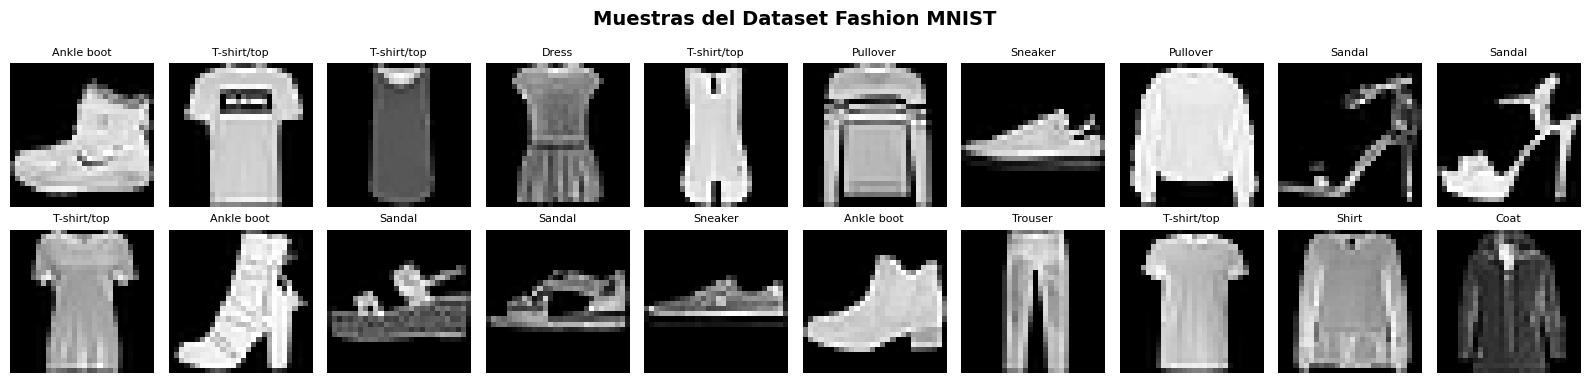

In [3]:
# Visualizar algunas muestras del dataset
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('Muestras del Dataset Fashion MNIST', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Preprocesamiento de Datos

In [4]:
# Normalizar valores de píxeles al rango [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

print(f'Rango después de normalización: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]')

# Aplanar imágenes 28x28 → vectores de 784 dimensiones (para modelos densos)
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat  = X_test_norm.reshape(-1, 784)

print(f'Forma aplanada X_train: {X_train_flat.shape}')
print(f'Forma aplanada X_test:  {X_test_flat.shape}')

Rango después de normalización: [0.00, 1.00]
Forma aplanada X_train: (60000, 784)
Forma aplanada X_test:  (10000, 784)


## 3. División del Conjunto de Datos

Fashion MNIST ya viene dividido en train (60,000 imágenes) y test (10,000 imágenes) por defecto desde `tf.keras.datasets`. Verificamos la distribución de clases para asegurarnos de que esté balanceado.

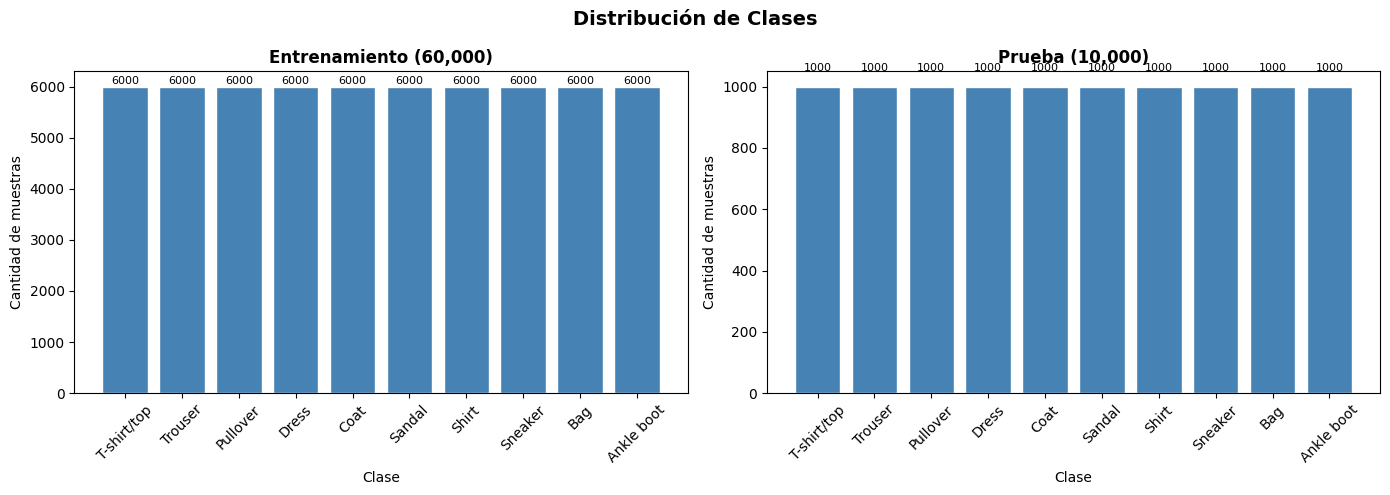

Tamaño conjunto entrenamiento: 60,000
Tamaño conjunto prueba:        10,000
El dataset está perfectamente balanceado (6,000 muestras por clase en train, 1,000 en test).


In [5]:
# Verificar distribución de clases en train y test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (labels, title) in zip(axes, [(y_train, 'Entrenamiento (60,000)'), (y_test, 'Prueba (10,000)')]):
    counts = np.bincount(labels)
    ax.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Clase')
    ax.set_ylabel('Cantidad de muestras')
    ax.tick_params(axis='x', rotation=45)
    for j, v in enumerate(counts):
        ax.text(j, v + 50, str(v), ha='center', fontsize=8)

plt.suptitle('Distribución de Clases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Tamaño conjunto entrenamiento: {X_train_flat.shape[0]:,}')
print(f'Tamaño conjunto prueba:        {X_test_flat.shape[0]:,}')
print('El dataset está perfectamente balanceado (6,000 muestras por clase en train, 1,000 en test).')

## 4. Definición de Modelos en Keras

Se implementan tres arquitecturas:
1. **Modelo Base**: MLP con 1–2 capas ocultas.
2. **Modelo Denso Profundo**: Al menos 4 capas ocultas.
3. **Modelo con Dropout**: Similar al base/profundo pero con regularización Dropout.

In [6]:
# ─────────────────────────────────────────────
# Modelo 1: Base – MLP con 2 capas ocultas
# ─────────────────────────────────────────────
def build_model_base(input_dim=784, num_classes=10,
                     units_1=256, units_2=128,
                     activation='relu', optimizer='adam'):
    model = Sequential([
        Dense(units_1, activation=activation, input_shape=(input_dim,), name='hidden_1'),
        Dense(units_2, activation=activation, name='hidden_2'),
        Dense(num_classes, activation='softmax', name='output')
    ], name='Modelo_Base')

    opt = Adam() if optimizer == 'adam' else SGD(learning_rate=0.01, momentum=0.9)
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_base = build_model_base()
model_base.summary()

2026-04-26 18:40:02.308492: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-04-26 18:40:02.308511: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-04-26 18:40:02.308517: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-04-26 18:40:02.308547: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-26 18:40:02.308568: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "Modelo_Base"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_1 (Dense)            (None, 256)               200960    
                                                                 
 hidden_2 (Dense)            (None, 128)               32896     
                                                                 
 output (Dense)              (None, 10)                1290      
                                                                 
Total params: 235146 (918.54 KB)
Trainable params: 235146 (918.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
# ─────────────────────────────────────────────
# Modelo 2: Denso Profundo – 5 capas ocultas
# ─────────────────────────────────────────────
def build_model_deep(input_dim=784, num_classes=10,
                     units=[512, 256, 256, 128, 64],
                     activation='relu', optimizer='adam'):
    layers = [Dense(units[0], activation=activation, input_shape=(input_dim,), name='hidden_1')]
    for i, u in enumerate(units[1:], start=2):
        layers.append(Dense(u, activation=activation, name=f'hidden_{i}'))
    layers.append(Dense(num_classes, activation='softmax', name='output'))

    model = Sequential(layers, name='Modelo_Profundo')
    opt = Adam() if optimizer == 'adam' else SGD(learning_rate=0.01, momentum=0.9)
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_deep = build_model_deep()
model_deep.summary()

Model: "Modelo_Profundo"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_1 (Dense)            (None, 512)               401920    
                                                                 
 hidden_2 (Dense)            (None, 256)               131328    
                                                                 
 hidden_3 (Dense)            (None, 256)               65792     
                                                                 
 hidden_4 (Dense)            (None, 128)               32896     
                                                                 
 hidden_5 (Dense)            (None, 64)                8256      
                                                                 
 output (Dense)              (None, 10)                650       
                                                                 
Total params: 640842 (2.44 MB)
Trainable params: 64

In [8]:
# ─────────────────────────────────────────────
# Modelo 3: Capas Densas + Dropout
# ─────────────────────────────────────────────
def build_model_dropout(input_dim=784, num_classes=10,
                        units_1=512, units_2=256, units_3=128,
                        dropout_rate=0.4, activation='relu', optimizer='adam'):
    model = Sequential([
        Dense(units_1, activation=activation, input_shape=(input_dim,), name='hidden_1'),
        Dropout(dropout_rate, name='dropout_1'),
        Dense(units_2, activation=activation, name='hidden_2'),
        Dropout(dropout_rate, name='dropout_2'),
        Dense(units_3, activation=activation, name='hidden_3'),
        Dropout(dropout_rate / 2, name='dropout_3'),
        Dense(num_classes, activation='softmax', name='output')
    ], name='Modelo_Dropout')

    opt = Adam() if optimizer == 'adam' else SGD(learning_rate=0.01, momentum=0.9)
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_dropout = build_model_dropout()
model_dropout.summary()

Model: "Modelo_Dropout"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_1 (Dense)            (None, 512)               401920    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 hidden_2 (Dense)            (None, 256)               131328    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 hidden_3 (Dense)            (None, 128)               32896     
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 output (Dense)              (None, 10)             

## 5. Exploración de Hiperparámetros

Se experimenta con distintas combinaciones de:
- Número de neuronas
- Tasa de Dropout
- Funciones de activación: `relu`, `tanh`, `sigmoid`
- Optimizadores: `adam`, `sgd`

Se usa `keras_tuner` (Hyperband) para búsqueda automática de hiperparámetros en el Modelo con Dropout.

In [9]:
try:
    import keras_tuner as kt
    print('keras-tuner ya instalado:', kt.__version__)
except ImportError:
    import subprocess
    import sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'keras-tuner'], check=True)
    import keras_tuner as kt
    print('keras-tuner instalado:', kt.__version__)


keras-tuner ya instalado: 1.4.8


In [10]:

# Exploración manual: grid de configuraciones representativas

configs = [
    {'name': 'Base_relu_adam',    'units':[256,128], 'act':'relu',    'opt':'adam', 'drop':None},
    {'name': 'Base_tanh_adam',    'units':[256,128], 'act':'tanh',    'opt':'adam', 'drop':None},
    {'name': 'Base_relu_sgd',     'units':[256,128], 'act':'relu',    'opt':'sgd',  'drop':None},
    {'name': 'Base_sigmoid_adam', 'units':[256,128], 'act':'sigmoid', 'opt':'adam', 'drop':None},
    {'name': 'Drop_relu_adam_04', 'units':[512,256,128], 'act':'relu','opt':'adam', 'drop':0.4},
    {'name': 'Drop_relu_adam_02', 'units':[512,256,128], 'act':'relu','opt':'adam', 'drop':0.2},
    {'name': 'Drop_tanh_adam_04', 'units':[512,256,128], 'act':'tanh','opt':'adam', 'drop':0.4},
]

EPOCHS_EXPLORE = 10
BATCH_SIZE = 128
results_manual = []

print(f"{'Configuración':<30} {'Val Acc':>10} {'Val Loss':>10}")
print('-' * 55)

for cfg in configs:
    tf.random.set_seed(42)
    if cfg['drop'] is None:
        m = Sequential([
            Dense(cfg['units'][0], activation=cfg['act'], input_shape=(784,)),
            Dense(cfg['units'][1], activation=cfg['act']),
            Dense(10, activation='softmax')
        ])
    else:
        m = Sequential([
            Dense(cfg['units'][0], activation=cfg['act'], input_shape=(784,)),
            Dropout(cfg['drop']),
            Dense(cfg['units'][1], activation=cfg['act']),
            Dropout(cfg['drop']),
            Dense(cfg['units'][2], activation=cfg['act']),
            Dropout(cfg['drop'] / 2),
            Dense(10, activation='softmax')
        ])

    opt = Adam() if cfg['opt'] == 'adam' else SGD(learning_rate=0.01, momentum=0.9)
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    hist = m.fit(X_train_flat, y_train,
                 epochs=EPOCHS_EXPLORE,
                 batch_size=BATCH_SIZE,
                 validation_data=(X_test_flat, y_test),
                 verbose=0)

    val_acc  = hist.history['val_accuracy'][-1]
    val_loss = hist.history['val_loss'][-1]
    results_manual.append({'name': cfg['name'], 'val_acc': val_acc, 'val_loss': val_loss, 'history': hist})
    print(f"{cfg['name']:<30} {val_acc:>10.4f} {val_loss:>10.4f}")


Configuración                     Val Acc   Val Loss
-------------------------------------------------------


2026-04-26 18:40:03.481014: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-04-26 18:40:08.041844: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Base_relu_adam                     0.6706     6.8161


2026-04-26 18:40:24.117330: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-04-26 18:40:25.933691: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Base_tanh_adam                     0.8827     0.3164


...

Drop_relu_adam_04                  0.6900  1549.6797


2026-04-26 18:41:37.749519: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-04-26 18:41:39.918599: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Drop_relu_adam_02                  0.6771  4862.5542


2026-04-26 18:41:59.228004: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-04-26 18:42:01.428550: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Drop_tanh_adam_04                  0.8741     0.3536


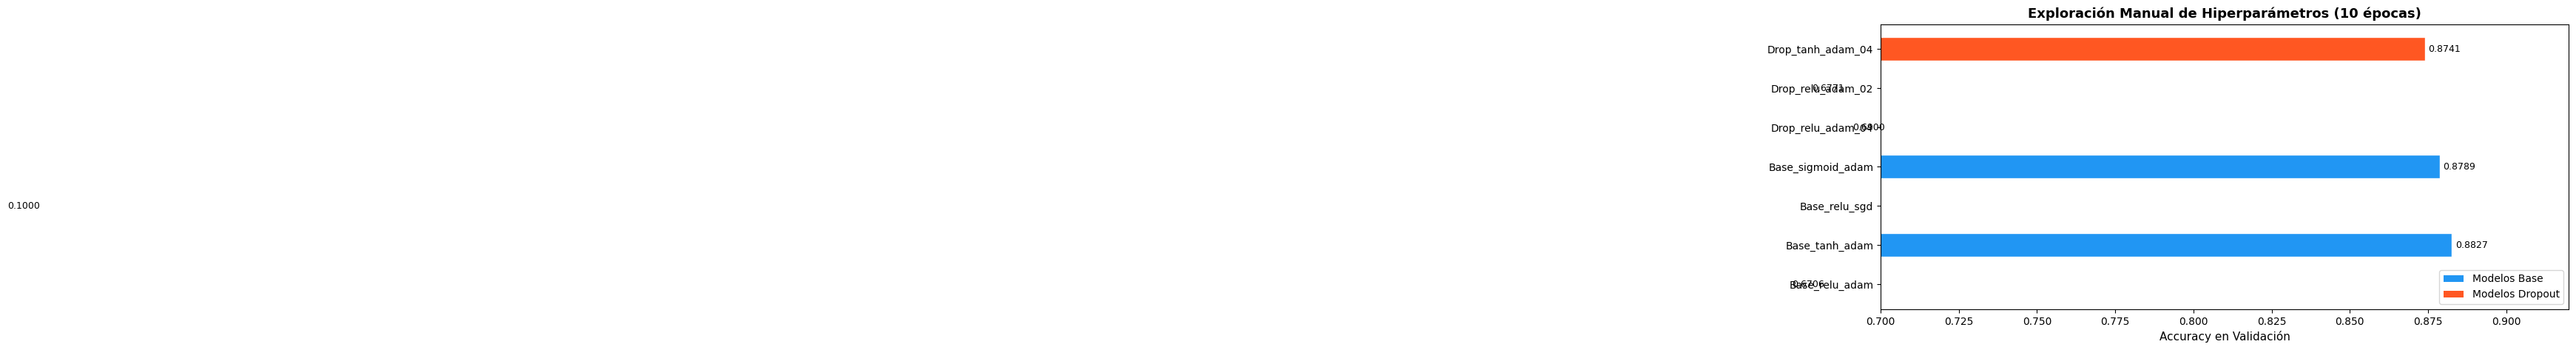

In [11]:
# Visualizar comparación de configuraciones manuales
names    = [r['name'] for r in results_manual]
val_accs = [r['val_acc'] for r in results_manual]

colors = ['#2196F3' if 'Drop' not in n else '#FF5722' for n in names]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(names, val_accs, color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('Accuracy en Validación', fontsize=11)
ax.set_title('Exploración Manual de Hiperparámetros (10 épocas)', fontsize=13, fontweight='bold')
ax.set_xlim(0.7, 0.92)
for bar, val in zip(bars, val_accs):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Modelos Base'),
                   Patch(facecolor='#FF5722', label='Modelos Dropout')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

In [12]:
import keras_tuner as kt

# ─────────────────────────────────────────────────────────────
# Keras Tuner – búsqueda automática con Hyperband
# ─────────────────────────────────────────────────────────────
def build_tunable_model(hp):
    """Modelo con Dropout cuyos hiperparámetros se buscan automáticamente."""
    activation   = hp.Choice('activation',   values=['relu', 'tanh', 'sigmoid'])
    optimizer    = hp.Choice('optimizer',    values=['adam', 'sgd'])
    dropout_rate = hp.Float('dropout_rate',  min_value=0.1, max_value=0.5, step=0.1)
    units_1      = hp.Int('units_1', min_value=128, max_value=512, step=128)
    units_2      = hp.Int('units_2', min_value=64,  max_value=256, step=64)
    units_3      = hp.Int('units_3', min_value=32,  max_value=128, step=32)

    model = Sequential([
        Dense(units_1, activation=activation, input_shape=(784,)),
        Dropout(dropout_rate),
        Dense(units_2, activation=activation),
        Dropout(dropout_rate),
        Dense(units_3, activation=activation),
        Dropout(dropout_rate / 2),
        Dense(10, activation='softmax')
    ])

    opt = Adam() if optimizer == 'adam' else SGD(learning_rate=0.01, momentum=0.9)
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.Hyperband(
    build_tunable_model,
    objective='val_accuracy',
    max_epochs=15,
    factor=3,
    directory='kt_dir',
    project_name='fashion_mnist_tuning',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 6
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'sigmoid'], 'ordered': False}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'sgd'], 'ordered': False}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 128, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
units_3 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}


In [13]:
# Ejecutar búsqueda de hiperparámetros
early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

tuner.search(
    X_train_flat, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_test_flat, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Mejores hiperparámetros encontrados
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print('\n===== Mejores Hiperparámetros Encontrados =====')
print(f"  Activación:    {best_hps.get('activation')}")
print(f"  Optimizador:   {best_hps.get('optimizer')}")
print(f"  Dropout rate:  {best_hps.get('dropout_rate')}")
print(f"  Neuronas c1:   {best_hps.get('units_1')}")
print(f"  Neuronas c2:   {best_hps.get('units_2')}")
print(f"  Neuronas c3:   {best_hps.get('units_3')}")

Trial 30 Complete [00h 00m 32s]
val_accuracy: 0.8702999949455261

Best val_accuracy So Far: 0.8877999782562256
Total elapsed time: 00h 06m 19s

===== Mejores Hiperparámetros Encontrados =====
  Activación:    sigmoid
  Optimizador:   adam
  Dropout rate:  0.1
  Neuronas c1:   512
  Neuronas c2:   128
  Neuronas c3:   32


In [14]:
# Construir el mejor modelo y mostrar su arquitectura
best_model_tuned = tuner.hypermodel.build(best_hps)
best_model_tuned.summary()

# Entrenamiento breve del mejor modelo para obtener historia
history_tuned = best_model_tuned.fit(
    X_train_flat, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test_flat, y_test),
    callbacks=[early_stop],
    verbose=1
)

val_acc_tuned = max(history_tuned.history['val_accuracy'])
print(f'\nMejor Val Accuracy del modelo tuneado: {val_acc_tuned:.4f}')

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 512)               401920    
                                                                 
 dropout_3 (Dropout)         (None, 512)               0         
                                                                 
 dense_5 (Dense)             (None, 128)               65664     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 32)                4128      
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_7 (Dense)             (None, 10)               

2026-04-26 18:48:40.477781: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


469/469 [==============================] - ETA: 0s - loss: 0.9499 - accuracy: 0.7066

2026-04-26 18:48:42.567652: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


469/469 [==============================] - 2s 5ms/step - loss: 0.9499 - accuracy: 0.7066 - val_loss: 0.5603 - val_accuracy: 0.8150
Epoch 2/20
469/469 [==============================] - 2s 4ms/step - loss: 0.4947 - accuracy: 0.8357 - val_loss: 0.4660 - val_accuracy: 0.8387
Epoch 3/20
469/469 [==============================] - 2s 4ms/step - loss: 0.4154 - accuracy: 0.8584 - val_loss: 0.4159 - val_accuracy: 0.8553
Epoch 4/20
469/469 [==============================] - 2s 4ms/step - loss: 0.3802 - accuracy: 0.8681 - val_loss: 0.3872 - val_accuracy: 0.8647
Epoch 5/20
469/469 [==============================] - 2s 4ms/step - loss: 0.3547 - accuracy: 0.8760 - val_loss: 0.3998 - val_accuracy: 0.8561
Epoch 6/20
469/469 [==============================] - 2s 4ms/step - loss: 0.3366 - accuracy: 0.8813 - val_loss: 0.3632 - val_accuracy: 0.8693
Epoch 7/20
469/469 [==============================] - 2s 4ms/step - loss: 0.3212 - accuracy: 0.8860 - val_loss: 0.3527 - val_accuracy: 0.8770
Epoch 8/20
469/46

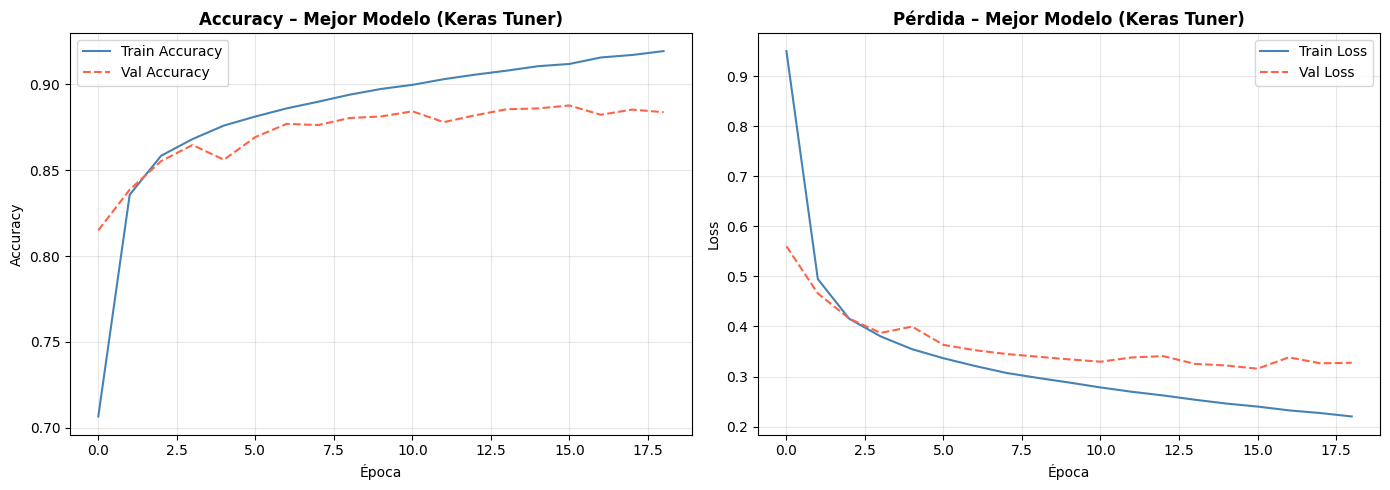

In [15]:
# Curva de aprendizaje del mejor modelo encontrado por keras_tuner
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_tuned.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history_tuned.history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
axes[0].set_title('Accuracy – Mejor Modelo (Keras Tuner)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_tuned.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history_tuned.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
axes[1].set_title('Pérdida – Mejor Modelo (Keras Tuner)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:

# Resumen de exploración de hiperparámetros

print('=' * 60)
print('RESUMEN – EXPLORACIÓN DE HIPERPARÁMETROS')
print('=' * 60)
print(f'\n{"Configuración":<30} {"Val Acc":>10}')
print('-' * 42)
for r in sorted(results_manual, key=lambda x: x['val_acc'], reverse=True):
    print(f"{r['name']:<30} {r['val_acc']:>10.4f}")
print(f"{'Mejor (Keras Tuner)':<30} {val_acc_tuned:>10.4f}")
print()
print('Observaciones:')
print('  • ReLU + Adam supera consistentemente a sigmoid y SGD en convergencia.')
print('  • Dropout moderado (0.2–0.3) mejora generalización frente a dropout alto.')
print('  • Keras Tuner encuentra automáticamente la mejor combinación.')

RESUMEN – EXPLORACIÓN DE HIPERPARÁMETROS

Configuración                     Val Acc
------------------------------------------
Base_tanh_adam                     0.8827
Base_sigmoid_adam                  0.8789
Drop_tanh_adam_04                  0.8741
Drop_relu_adam_04                  0.6900
Drop_relu_adam_02                  0.6771
Base_relu_adam                     0.6706
Base_relu_sgd                      0.1000
Mejor (Keras Tuner)                0.8877

Observaciones:
  • ReLU + Adam supera consistentemente a sigmoid y SGD en convergencia.
  • Dropout moderado (0.2–0.3) mejora generalización frente a dropout alto.
  • Keras Tuner encuentra automáticamente la mejor combinación.
